<h1 style="color: red; font-size: 48px; text-align: center;">Healthcare Claims Anomaly Detection</h1>

<center>
    <img src="https://upload.wikimedia.org/wikipedia/commons/e/e5/ECG_principle_slow.gif" alt="healthcare claims anomaly" height="220" width="520">
</center>

# 👋 Introduction

<div class="alert alert-block alert-success" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    The objective of this project is to build an <b>end-to-end, explainable fraud & abuse detection platform</b> for healthcare insurance claims.
    Every medical claim is assigned a composite <b>0–100 fraud risk score</b> by fusing provider behavioural clustering (K-Means),
    statistical anomaly detection (Isolation Forest), and clinical note alignment (ClinicalBERT). Claims scoring above the auto-triage
    threshold are routed for human review. The goal is to catch high-risk claims early while keeping every score auditable.
</div>

# 📚 Problem Statement

<div class="alert alert-block alert-info" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    US healthcare fraud, waste, and abuse costs the industry roughly <b>$300B annually</b>. Manual review costs about <b>$85 per claim</b>
    and still catches only <b>~12%</b> of fraudulent submissions. Reviewing every claim by hand is slow, expensive, and subjective.
    By learning the billing patterns of providers and the clinical consistency of each claim, we can automatically triage the
    highest-risk claims and surface the reasons behind each decision — improving both precision and accountability.
</div>

# 🔭 Feature Description

<div style="font-family:verdana; font-size: 20px; line-height: 1.7em;">
<ol>
<li><p><strong><code>provider_specialty</code></strong>: The billing provider's medical specialty (e.g., Cardiology, Orthopedics). Different specialties have very different typical billing profiles.</p></li>

<li><p><strong><code>provider_state</code></strong>: The US state of the rendering provider. Used for geographic risk triage.</p></li>

<li><p><strong><code>units</code></strong>: The number of service units billed on the claim line. Inflated unit counts can indicate unbundling or upcoding.</p></li>

<li><p><strong><code>allowed_amount</code></strong> / <strong><code>billed_amount</code></strong>: The payer-allowed amount versus the amount actually billed by the provider.</p></li>

<li><p><strong><code>typical_allowed_amount</code></strong>: The expected allowed amount for the procedure, used as a reference baseline for the billing ratio.</p></li>

<li><p><strong><code>billed_to_allowed_ratio</code></strong> / <strong><code>billed_to_typical_ratio</code></strong>: How far the billed amount deviates from the allowed and the typical amount. High ratios are a primary upcoding signal.</p></li>

<li><p><strong><code>provider_cluster</code></strong>: The K-Means behavioural cluster the provider was assigned to, so each claim is compared against its peer group.</p></li>

<li><p><strong><code>procedure_diagnosis_mismatch</code></strong>: A flag (1 = yes) indicating the billed CPT procedure is not clinically compatible with the ICD-10 diagnosis.</p></li>

<li><p><strong><code>upcoding_flag</code></strong> / <strong><code>unbundling_flag</code></strong>: Binary indicators of probable upcoding (billing a higher-cost code) and unbundling (splitting one encounter into many billed lines).</p></li>

<li><p><strong><code>anomaly_score</code></strong> / <strong><code>clinical_misalignment</code></strong> / <strong><code>billing_ratio_anomaly</code></strong>: The three independent detection signals fused into the composite score.</p></li>

<li><p><strong><code>fraud_risk_score</code></strong>: The composite 0–100 risk index, with a <code>risk_tier</code> of LOW / MEDIUM / HIGH.</p></li>

<li><p><strong><code>is_fraud_label</code></strong>: The synthetic ground-truth fraud label (1 = fraudulent). Used <i>only</i> for evaluation — never fed to the models.</p></li>
</ol>

<p>
Together these features capture the provider's billing behaviour, the financial profile of the claim, and the clinical consistency
of the diagnosis-procedure pairing — the three axes along which fraud, waste, and abuse usually appear.
</p>
</div>

# 🎯 Project Goals

<div class="alert alert-block alert-warning" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    <ul>
        <li>Perform exploratory data analysis (EDA) to understand provider billing behaviour and the fraud risk distribution.</li>
        <li>Engineer billing-ratio and behavioural-cluster features that separate normal from anomalous claims.</li>
        <li>Train anomaly-detection and classification models and compare them using ROC-AUC, F1, precision, and recall.</li>
        <li>Use model interpretation (feature importance / SHAP-style attribution) to explain each high-risk claim.</li>
        <li>Produce an auditable high-risk claim queue for the compliance team.</li>
    </ul>
</div>

# Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from rich.console import Console
from rich.table import Table

warnings.filterwarnings("ignore")

plt.style.use("ggplot")
sns.set(font_scale=1.1)

# Load Data

<div class="alert alert-block alert-info" style="font-family: verdana; font-size: 18px; line-height: 1.6em; border-radius: 1.3em;">
    The scored claims dataset is produced by the platform pipeline (<code>run_pipeline.py</code>) and saved to
    <code>output/scored/fraud_scores.csv</code>. The loader below first checks the repo paths and any attached
    Kaggle dataset — and if nothing is found (e.g. a fresh Kaggle session with <b>no dataset attached</b>), it
    <b>generates the same synthetic scored dataset directly in the notebook</b>: synthetic CMS-style claims →
    billing-ratio features → K-Means provider clusters → Isolation Forest anomaly score → composite 0–100
    fraud risk score (weights 0.40 / 0.30 / 0.30, identical to the platform pipeline). So the notebook runs
    end-to-end on Kaggle with zero setup.
</div>

In [2]:
import io
import random

from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# ICD-10 / CPT compatibility taxonomy (mirrors data/reference/icd10_cpt_compatibility.csv)
TAXONOMY_CSV = """icd10_code,icd10_description,cpt_code,cpt_description,compatible,typical_allowed_amount
E11.9,Type 2 diabetes mellitus without complications,99214,Office visit established patient moderate,1,180
E11.9,Type 2 diabetes mellitus without complications,83036,Hemoglobin A1c,1,55
E11.9,Type 2 diabetes mellitus without complications,93000,Electrocardiogram routine,0,75
I10,Essential hypertension,99213,Office visit established patient low,1,120
I10,Essential hypertension,93000,Electrocardiogram routine,1,75
I10,Essential hypertension,29881,Knee arthroscopy meniscectomy,0,3400
J45.909,Unspecified asthma uncomplicated,94010,Spirometry,1,90
J45.909,Unspecified asthma uncomplicated,99214,Office visit established patient moderate,1,180
J45.909,Unspecified asthma uncomplicated,45378,Colonoscopy diagnostic,0,1200
M54.5,Low back pain,72148,MRI lumbar spine without contrast,1,1100
M54.5,Low back pain,97110,Therapeutic exercise,1,65
M54.5,Low back pain,33533,Coronary artery bypass graft,0,52000
M17.11,Unilateral primary osteoarthritis right knee,29881,Knee arthroscopy meniscectomy,1,3400
M17.11,Unilateral primary osteoarthritis right knee,73721,MRI lower extremity joint,1,1000
M17.11,Unilateral primary osteoarthritis right knee,99204,Office visit new patient moderate,1,210
N39.0,Urinary tract infection,81003,Urinalysis automated,1,25
N39.0,Urinary tract infection,99213,Office visit established patient low,1,120
J18.9,Pneumonia unspecified organism,71046,Chest x-ray two views,1,110
J18.9,Pneumonia unspecified organism,99223,Initial hospital care high,1,420
J18.9,Pneumonia unspecified organism,99291,Critical care first hour,0,750
K21.9,Gastro-esophageal reflux disease,43239,Upper GI endoscopy biopsy,1,1500
K21.9,Gastro-esophageal reflux disease,99213,Office visit established patient low,1,120
I21.4,Non-ST elevation myocardial infarction,93458,Cardiac catheterization,1,4800
I21.4,Non-ST elevation myocardial infarction,99223,Initial hospital care high,1,420
I21.4,Non-ST elevation myocardial infarction,97110,Therapeutic exercise,0,65
Z00.00,General adult medical examination,99395,Preventive visit established 18-39,1,200
Z00.00,General adult medical examination,80053,Comprehensive metabolic panel,1,45
F32.9,Major depressive disorder single episode,90834,Psychotherapy 45 minutes,1,140
F32.9,Major depressive disorder single episode,99214,Office visit established patient moderate,1,180
O80,Encounter for full-term uncomplicated delivery,59400,Routine obstetric care vaginal delivery,1,4500
O80,Encounter for full-term uncomplicated delivery,76805,Obstetric ultrasound,1,250
"""

SPECIALTIES = ["Family Medicine", "Internal Medicine", "Cardiology", "Orthopedics",
               "Pulmonology", "Gastroenterology", "OB/GYN", "Psychiatry"]
STATES = ["CA", "TX", "NY", "FL", "IL", "PA"]

SCORE_WEIGHTS = {"anomaly_score": 0.40, "clinical_misalignment": 0.30, "billing_ratio_anomaly": 0.30}
DRIVER_NAMES = {
    "anomaly_score": "Billing anomaly (Isolation Forest)",
    "clinical_misalignment": "Diagnosis-procedure note misalignment (ClinicalBERT)",
    "billing_ratio_anomaly": "Billing-ratio outlier within provider cluster",
}


def generate_scored_claims(n_claims=8000, n_providers=120, seed=42, fraud_rate=0.12):
    """Self-contained miniature of the platform pipeline: generates synthetic
    claims and scores them, producing the same schema as fraud_scores.csv."""
    rng = random.Random(seed)
    np_rng = np.random.default_rng(seed)
    taxonomy = pd.read_csv(io.StringIO(TAXONOMY_CSV))

    # ---- 1) Provider population (some are abusive billers) ----
    providers = [
        {"provider_id": f"PRV{i:05d}",
         "provider_specialty": rng.choice(SPECIALTIES),
         "provider_state": rng.choice(STATES),
         "abusive": rng.random() < 0.10}
        for i in range(n_providers)
    ]

    # ---- 2) Claim lines with seeded fraud patterns ----
    rows = []
    for c in range(n_claims):
        prov = rng.choice(providers)
        tax = taxonomy.iloc[rng.randrange(len(taxonomy))]
        is_fraud = rng.random() < (fraud_rate * (3.0 if prov["abusive"] else 1.0))

        compatible = int(tax["compatible"])
        cpt_code, cpt_desc, typical = tax["cpt_code"], tax["cpt_description"], float(tax["typical_allowed_amount"])
        if is_fraud and rng.random() < 0.5:  # procedure-diagnosis mismatch
            wrong = taxonomy[taxonomy["icd10_code"] != tax["icd10_code"]].sample(
                1, random_state=int(np_rng.integers(0, 1_000_000))).iloc[0]
            cpt_code, cpt_desc, typical = wrong["cpt_code"], wrong["cpt_description"], float(wrong["typical_allowed_amount"])
            compatible = 0

        units = rng.randint(1, 3)
        allowed = round(typical * units * np_rng.uniform(0.9, 1.1), 2)
        # Overlapping billing behaviour: most fraud inflates the bill, some hides
        # behind normal-looking amounts; honest billing can also drift high.
        if is_fraud:
            billed_mult = np_rng.uniform(1.8, 6.0) if rng.random() < 0.8 else np_rng.uniform(1.0, 1.4)
        else:
            billed_mult = np_rng.uniform(1.0, 2.2)
        note_aligned = rng.random() < (0.3 if is_fraud else 0.95)

        rows.append({
            "claim_id": f"CLM{c:08d}",
            "provider_id": prov["provider_id"],
            "provider_specialty": prov["provider_specialty"],
            "provider_state": prov["provider_state"],
            "claim_date": pd.Timestamp(f"{rng.choice([2024, 2025])}-01-01")
                          + pd.Timedelta(days=int(np_rng.integers(0, 364))),
            "icd10_code": tax["icd10_code"],
            "icd10_description": tax["icd10_description"],
            "cpt_code": str(cpt_code),
            "cpt_description": cpt_desc,
            "units": units,
            "allowed_amount": allowed,
            "billed_amount": round(allowed * billed_mult, 2),
            "typical_allowed_amount": typical,
            "_compatible": compatible,
            "_note_aligned": note_aligned,
            "is_fraud_label": int(is_fraud),
        })
    df = pd.DataFrame(rows)

    # ---- 3) Billing-ratio features ----
    df["billed_to_allowed_ratio"] = df["billed_amount"] / df["allowed_amount"]
    df["billed_to_typical_ratio"] = df["billed_amount"] / df["typical_allowed_amount"]

    # ---- 4) K-Means behavioural clusters on the per-provider billing profile ----
    prof = df.groupby("provider_id").agg(
        mean_billed=("billed_amount", "mean"),
        mean_ratio=("billed_to_allowed_ratio", "mean"),
        mean_units=("units", "mean"),
        claim_volume=("claim_id", "count"),
    )
    km = KMeans(n_clusters=6, n_init=10, random_state=seed)
    prof["provider_cluster"] = km.fit_predict(StandardScaler().fit_transform(prof))
    df = df.merge(prof["provider_cluster"], left_on="provider_id", right_index=True)

    # ---- 5) Isolation Forest anomaly score (normalized to 0-1) ----
    iso_feats = df[["units", "allowed_amount", "billed_amount",
                    "billed_to_allowed_ratio", "billed_to_typical_ratio"]]
    iso = IsolationForest(n_estimators=200, contamination=0.05, random_state=seed)
    iso.fit(iso_feats)
    raw = -iso.score_samples(iso_feats)
    df["anomaly_score"] = (raw - raw.min()) / (raw.max() - raw.min())
    df["anomaly_flag"] = (iso.predict(iso_feats) == -1).astype(int)

    # ---- 6) Clinical note misalignment (ClinicalBERT proxy, noisy not perfect) ----
    base = np.where(df["_note_aligned"], 1 / 3, 0.85)
    df["clinical_misalignment"] = np.clip(base + np_rng.normal(0, 0.12, len(df)), 0, 1)

    # ---- 7) Billing-ratio anomaly: z-score within the provider cluster ----
    z = df.groupby("provider_cluster")["billed_to_allowed_ratio"].transform(
        lambda s: (s - s.mean()) / (s.std() + 1e-9))
    df["billing_ratio_anomaly"] = np.clip(z / 3, 0, 1)

    # ---- 8) Rule-based flags ----
    df["procedure_diagnosis_mismatch"] = 1 - df["_compatible"]
    df["upcoding_flag"] = (df["billed_to_typical_ratio"] > 2.0).astype(int)
    df["unbundling_flag"] = (df.groupby(["provider_id", "claim_date", "icd10_code"])
                               ["claim_id"].transform("count") > 2).astype(int)

    # ---- 9) Composite 0-100 fraud risk score (same fusion as the platform) ----
    contribs = pd.DataFrame({k: w * df[k] for k, w in SCORE_WEIGHTS.items()})
    df["fraud_risk_score"] = (contribs.sum(axis=1) * 100).clip(0, 100).round(2)
    df["risk_tier"] = pd.cut(df["fraud_risk_score"], bins=[-0.1, 40, 75, 100],
                             labels=["LOW", "MEDIUM", "HIGH"]).astype(str)
    df["high_risk_flag"] = (df["fraud_risk_score"] > 75).astype(int)
    ranked = contribs.values.argsort(axis=1)[:, ::-1]
    names = np.array([DRIVER_NAMES[c] for c in contribs.columns])
    df["top_risk_drivers"] = ["; ".join(names[r]) for r in ranked]

    cols = ["claim_id", "provider_id", "provider_specialty", "provider_state", "claim_date",
            "icd10_code", "icd10_description", "cpt_code", "cpt_description", "units",
            "allowed_amount", "billed_amount", "typical_allowed_amount",
            "billed_to_allowed_ratio", "billed_to_typical_ratio", "provider_cluster",
            "anomaly_score", "anomaly_flag", "clinical_misalignment", "billing_ratio_anomaly",
            "procedure_diagnosis_mismatch", "upcoding_flag", "unbundling_flag",
            "fraud_risk_score", "risk_tier", "high_risk_flag", "top_risk_drivers", "is_fraud_label"]
    return df[cols]

In [3]:
import os
import glob

CANDIDATE_PATHS = [
    "../output/scored/fraud_scores.csv",   # repo-relative (kaggle/ folder)
    "output/scored/fraud_scores.csv",      # repo root
]
# Any attached Kaggle dataset that contains fraud_scores.csv (no fixed dataset name needed)
CANDIDATE_PATHS += sorted(glob.glob("/kaggle/input/**/fraud_scores.csv", recursive=True))

data_path = next((p for p in CANDIDATE_PATHS if os.path.exists(p)), None)

if data_path is not None:
    df = pd.read_csv(data_path, parse_dates=["claim_date"])
    print(f"Loaded {df.shape[0]:,} claims x {df.shape[1]} columns from {data_path}")
else:
    print("fraud_scores.csv not found -> generating the synthetic scored dataset in-notebook...")
    df = generate_scored_claims(n_claims=8000, n_providers=120, seed=42)
    df.to_csv("fraud_scores.csv", index=False)  # saved to /kaggle/working on Kaggle
    print(f"Generated {df.shape[0]:,} claims x {df.shape[1]} columns (saved to fraud_scores.csv)")

Loaded 5,000 claims x 28 columns from ../output/scored/fraud_scores.csv


In [4]:
df.head()

,claim_id,provider_id,provider_specialty,provider_state,claim_date,icd10_code,icd10_description,cpt_code,cpt_description,units,...,clinical_misalignment,billing_ratio_anomaly,procedure_diagnosis_mismatch,upcoding_flag,unbundling_flag,fraud_risk_score,risk_tier,high_risk_flag,top_risk_drivers,is_fraud_label
0,CLM00000000,PRV00095,Gastroenterology,CA,2025-06-07,F32.9,Major depressive disorder single episode,99214,Office visit established patient moderate,3,...,0.333333,0.133596,0,1,0,15.90,LOW,0,Diagnosis-procedure note misalignment (Clinica...,0
1,CLM00000001,PRV00036,Orthopedics,TX,2025-07-11,N39.0,Urinary tract infection,99213,Office visit established patient low,3,...,0.333333,0.361966,0,1,0,23.75,LOW,0,Billing-ratio outlier within provider cluster;...,0
2,CLM00000002,PRV00063,Orthopedics,FL,2024-07-05,M17.11,Unilateral primary osteoarthritis right knee,29881,Knee arthroscopy meniscectomy,3,...,0.333333,0.195269,0,1,0,27.94,LOW,0,Statistical billing anomaly (Isolation Forest)...,0
3,CLM00000003,PRV00096,Orthopedics,PA,2025-03-08,F32.9,Major depressive disorder single episode,99214,Office visit established patient moderate,3,...,0.333333,0.195799,0,1,0,17.53,LOW,0,Diagnosis-procedure note misalignment (Clinica...,0
4,CLM00000004,PRV00030,Psychiatry,IL,2024-07-17,J45.909,Unspecified asthma uncomplicated,45378,Colonoscopy diagnostic,1,...,0.333333,0.841182,1,1,0,58.41,MEDIUM,0,Billing-ratio outlier within provider cluster;...,1


In [5]:
def custom_describe(df, categorical=False):

    if not categorical:
        df = df.select_dtypes(include=np.number)

    des = df.describe().T.round(2)
    des['count'] = des['count'].astype('int')

    if not categorical:
        des['skewness'] = df.skew().round(2)
        des['kurtosis'] = df.kurtosis().round(2)

    return des

In [6]:
def df_summary(df, label="Claims"):
    console = Console()
    console.rule(f"[bold blue]{label} DataFrame Description[/bold blue]")

    console.print(f"[bold]Shape:[/bold] {df.shape}\n")

    # Numeric summary
    numeric_cols = df.select_dtypes(include=np.number).columns
    if len(numeric_cols) > 0:
        console.print("[bold blue]Numerical Columns:[/bold blue]")
        num_stats = custom_describe(df[numeric_cols], categorical=False)
        table = Table(show_header=True, header_style="bold magenta")
        table.add_column("Column")
        for col in num_stats.columns:
            table.add_column(col)
        for idx, row in num_stats.iterrows():
            table.add_row(idx, *[f"{val:.2f}" if isinstance(val, (float, np.float64)) else str(val) for val in row])
        console.print(table)
        console.print("\n")

    # Categorical summary
    cat_cols = df.select_dtypes(include=['object', 'category']).columns
    if len(cat_cols) > 0:
        console.print("[bold blue]Categorical Columns:[/bold blue]")
        cat_stats = df[cat_cols].describe().T
        table = Table(show_header=True, header_style="bold magenta")
        table.add_column("Column")
        for col in cat_stats.columns:
            table.add_column(col)
        for idx, row in cat_stats.iterrows():
            table.add_row(idx, *[str(val) for val in row])
        console.print(table)
        console.print("\n")

df_summary(df)

────────────────────────────────────────── Claims DataFrame Description ───────────────────────────────────────────

Shape: (5000, 28)

Numerical Columns:

┏━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┓
┃ Column  ┃ count   ┃ mean    ┃ std      ┃ min     ┃ 25%      ┃ 50%     ┃ 75%      ┃ max     ┃ skewness ┃ kurtos… ┃
┡━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━┩
│ cpt_co… │ 5000.00 │ 81660.… │ 22550.45 │ 29881.… │ 72148.00 │ 93000.… │ 99213.00 │ 99395.… │ -1.20    │ 0.10    │
│ units   │ 5000.00 │ 1.98    │ 0.81     │ 1.00    │ 1.00     │ 2.00    │ 3.00     │ 3.00    │ 0.04     │ -1.49   │
│ allowe… │ 5000.00 │ 4459.90 │ 18181.66 │ 22.58   │ 169.98   │ 381.52  │ 2000.53  │ 171343… │ 6.85     │ 49.69   │
│ billed… │ 5000.00 │ 7560.57 │ 36388.11 │ 23.50   │ 224.44   │ 545.07  │ 2675.84  │ 714895… │ 10.44    │ 139.91  │
│ typica… │ 5000.00 │ 2517.25 │ 10247.63 │ 23.87   │ 110.00   │ 200.00  │ 1100.00  │ 169352… │ 7.45     │ 71.88   │
│ billed… │ 5000.00 │ 1.64    │ 1.14     │ 1.00    │ 1.12     │ 1.23    │ 1.35     │ 6.00    │ 2.45     │ 4.69    │
│ billed… │ 5000.00 │ 2.94    │ 2.17     │ 0.91    │ 1.35     │ 2.55    │ 3.58     │ 18.89   │ 3.25     │ 14.98   │
│ provid… │ 5000.00 │ 3.18    │ 2.29     │ 0.00    │ 1.00     │ 4.00    │ 5.00     │ 7.00    │ -0.11    │ -1.39   │
│ anomal… │ 5000.00 │ 0.17    │ 0.19     │ 0.00    │ 0.04     │ 0.08    │ 0.26     │ 1.00    │ 1.86     │ 3.34    │
│ anomal… │ 5000.00 │ 0.08    │ 0.27     │ 0.00    │ 0.00     │ 0.00    │ 0.00     │ 1.00    │ 3.10     │ 7.60    │
│ clinic… │ 5000.00 │ 0.65    │ 0.39     │ 0.00    │ 0.33     │ 1.00    │ 1.00     │ 1.00    │ -0.43    │ -1.45   │
│ billin… │ 5000.00 │ 0.30    │ 0.25     │ 0.00    │ 0.14     │ 0.25    │ 0.34     │ 0.94    │ 1.41     │ 1.03    │
│ proced… │ 5000.00 │ 0.24    │ 0.43     │ 0.00    │ 0.00     │ 0.00    │ 0.00     │ 1.00    │ 1.19     │ -0.57   │
│ upcodi… │ 5000.00 │ 0.69    │ 0.46     │ 0.00    │ 0.00     │ 1.00    │ 1.00     │ 1.00    │ -0.80    │ -1.36   │
│ unbund… │ 5000.00 │ 0.00    │ 0.00     │ 0.00    │ 0.00     │ 0.00    │ 0.00     │ 0.00    │ 0.00     │ 0.00    │
│ fraud_… │ 5000.00 │ 35.15   │ 18.89    │ 0.34    │ 20.55    │ 34.92   │ 43.02    │ 97.60   │ 0.74     │ 0.27    │
│ high_r… │ 5000.00 │ 0.04    │ 0.21     │ 0.00    │ 0.00     │ 0.00    │ 0.00     │ 1.00    │ 4.41     │ 17.49   │
│ is_fra… │ 5000.00 │ 0.14    │ 0.35     │ 0.00    │ 0.00     │ 0.00    │ 0.00     │ 1.00    │ 2.04     │ 2.18    │
└─────────┴─────────┴─────────┴──────────┴─────────┴──────────┴─────────┴──────────┴─────────┴──────────┴─────────┘

Categorical Columns:

┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━┓
┃ Column             ┃ count ┃ unique ┃ top                                                                ┃ freq ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━┩
│ claim_id           │ 5000  │ 5000   │ CLM00000000                                                        │ 1    │
│ provider_id        │ 5000  │ 120    │ PRV00013                                                           │ 62   │
│ provider_specialty │ 5000  │ 8      │ Internal Medicine                                                  │ 896  │
│ provider_state     │ 5000  │ 6      │ TX                                                                 │ 1364 │
│ icd10_code         │ 5000  │ 12     │ I10                                                                │ 509  │
│ icd10_description  │ 5000  │ 12     │ Essential hypertension                                             │ 509  │
│ cpt_description    │ 5000  │ 23     │ Office visit established patient low                               │ 493  │
│ risk_tier          │ 5000  │ 3      │ LOW                                                                │ 3309 │
│ top_risk_drivers   │ 5000  │ 38     │ Diagnosis-procedure note misalignment (ClinicalBERT);              │ 1425 │
│                    │       │        │ Billing-ratio outlier within provider cluster; Statistical billing │      │
│                    │       │        │ anomaly (Isolation Forest)                                         │      │
└────────────────────┴───────┴────────┴────────────────────────────────────────────────────────────────────┴──────┘

# 🔍 Exploratory Data Analysis (EDA)

<div class="alert alert-block alert-success" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    The goal of Exploratory Data Analysis (EDA) is to understand the structure of the claims data and the patterns that
    distinguish normal claims from fraudulent ones. By visualizing the billing features, the fraud risk score, and the
    relationships between them, we can see which provider behaviours and clinical mismatches drive risk.
</div>

## 📊 Key Objectives of EDA

<div class="alert alert-block alert-info" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    <ul>
        <li>Examine the distribution of each billing feature and detect outliers (extreme billed-to-allowed ratios).</li>
        <li>Understand the relationship between <code>fraud_risk_score</code> and the underlying signals.</li>
        <li>Visualize how risk varies across <code>provider_specialty</code>, <code>provider_state</code>, and <code>provider_cluster</code>.</li>
        <li>Assess how flags like <code>upcoding_flag</code> and <code>procedure_diagnosis_mismatch</code> relate to fraud.</li>
        <li>Identify feature correlations and multicollinearity using a correlation heatmap.</li>
    </ul>
</div>

## 📈 Exploratory Steps

<div style="font-family: verdana; font-size: 20px; line-height: 1.7em;">
<ol>
<li><p><strong>Check for Missing Values:</strong> Verify data completeness with <code>isnull()</code> checks before any modelling.</p></li>

<li><p><strong>Univariate Analysis:</strong> Explore individual feature distributions:
    <ul>
        <li>Distribution of <code>billed_to_allowed_ratio</code> and <code>billed_amount</code></li>
        <li>Frequency counts of <code>provider_specialty</code>, <code>risk_tier</code>, and the fraud flags</li>
    </ul>
</p></li>

<li><p><strong>Target Analysis:</strong> Study the distribution of the composite <code>fraud_risk_score</code> and the LOW / MEDIUM / HIGH tiers.</p></li>

<li><p><strong>Bivariate Analysis:</strong> Relate the target to each feature:
    <ul>
        <li>Average fraud risk per <code>provider_specialty</code> and <code>provider_cluster</code></li>
        <li>Fraud risk by <code>upcoding_flag</code> and <code>procedure_diagnosis_mismatch</code></li>
        <li>Regression of billing ratios vs <code>fraud_risk_score</code></li>
    </ul>
</p></li>

<li><p><strong>Correlation Analysis:</strong> Compute the correlation matrix for numerical features and visualize it as a heatmap.</p></li>

<li><p><strong>Outlier Detection:</strong> Detect extreme billing ratios that often correspond to upcoding or unbundling.</p></li>
</ol>

<p>
The insights gained from EDA guide feature selection and model design, and help explain which combinations of billing behaviour
and clinical mismatch increase fraud risk.
</p>
</div>

In [7]:
target = "fraud_risk_score"
label = "is_fraud_label"

# Base claim features (exclude leakage: derived scores, ids, free text, the label itself)
leakage = [
    "fraud_risk_score", "risk_tier", "high_risk_flag", "top_risk_drivers",
    "anomaly_score", "anomaly_flag", "clinical_misalignment", "billing_ratio_anomaly",
    "is_fraud_label", "claim_id", "provider_id", "claim_date",
    "icd10_code", "icd10_description", "cpt_code", "cpt_description",
]
features = [c for c in df.columns if c not in leakage]
numerical_features = df[features].select_dtypes(include=np.number).columns.to_list()
categorical_features = df[features].select_dtypes(exclude=np.number).columns.to_list()

print("Numerical features  :", numerical_features)
print("Categorical features:", categorical_features)

Numerical features  : ['units', 'allowed_amount', 'billed_amount', 'typical_allowed_amount', 'billed_to_allowed_ratio', 'billed_to_typical_ratio', 'provider_cluster', 'procedure_diagnosis_mismatch', 'upcoding_flag', 'unbundling_flag']
Categorical features: ['provider_specialty', 'provider_state']


## Null Value Check

In [8]:
pd.DataFrame({
    'Columns': df.columns.to_list(),
    '# Null': df.isna().sum().values
})

,Columns,# Null
0,claim_id,0
1,provider_id,0
2,provider_specialty,0
3,provider_state,0
4,claim_date,0
5,icd10_code,0
6,icd10_description,0
7,cpt_code,0
8,cpt_description,0
9,units,0


## Duplicate Check

In [9]:
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

if num_duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)

Number of duplicate rows: 0


## Univariate Analysis

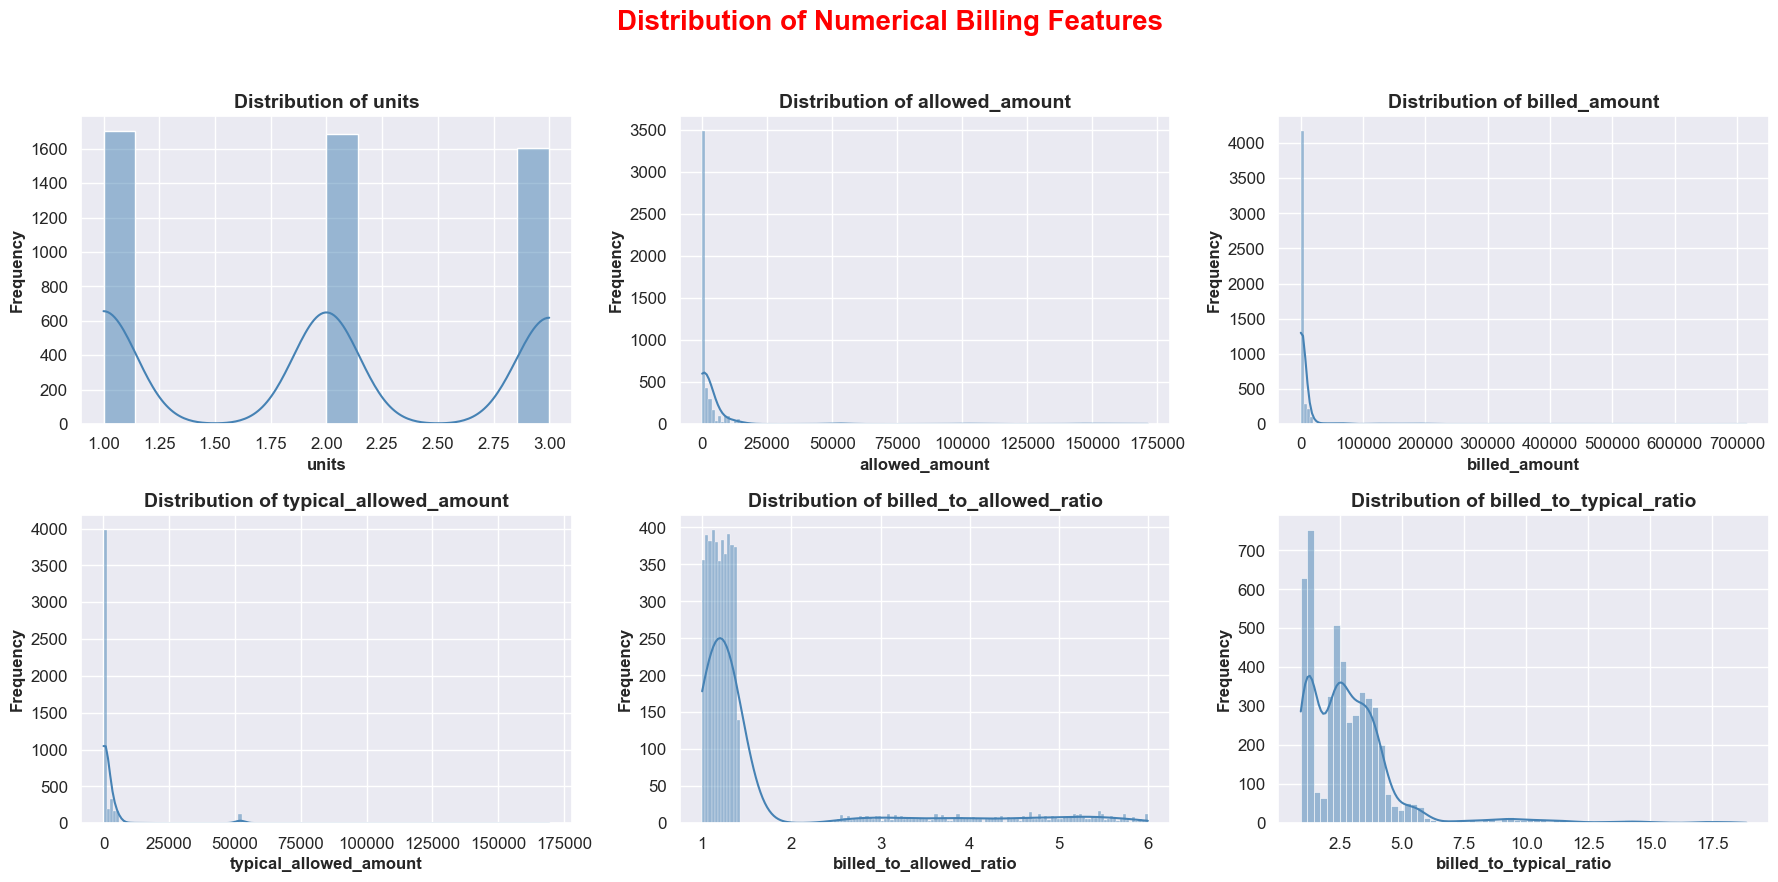

In [10]:
plot_num = [f for f in numerical_features if df[f].nunique() > 2][:6]

n = len(plot_num)
rows = (n + 2) // 3
fig, axes = plt.subplots(rows, 3, figsize=(18, 4.5 * rows))
axes = np.array(axes).flatten()

for i, feature in enumerate(plot_num):
    sns.histplot(data=df, x=feature, ax=axes[i], kde=True, color='steelblue')
    axes[i].set_title(f"Distribution of {feature}", fontweight="bold", fontsize=14)
    axes[i].set_xlabel(feature, fontsize=12, fontweight="bold")
    axes[i].set_ylabel("Frequency", fontsize=12, fontweight="bold")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Distribution of Numerical Billing Features", fontsize=20, fontweight="bold", color="red")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

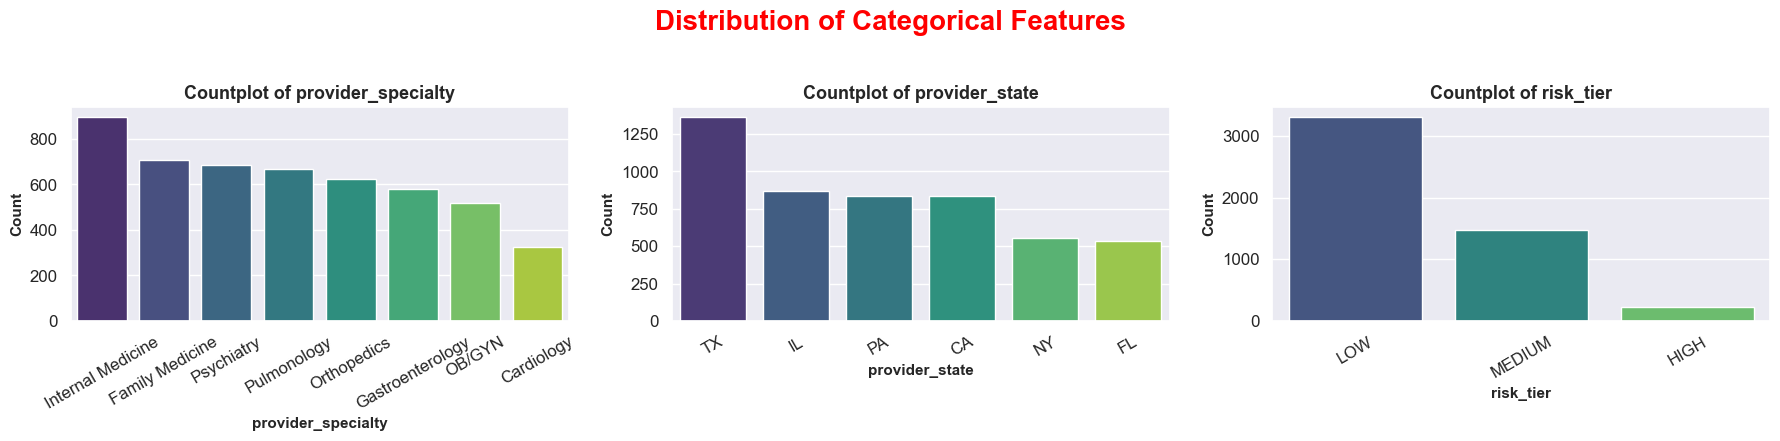

In [11]:
cat_plot = categorical_features + ['risk_tier']
n = len(cat_plot)
rows = (n + 2) // 3
fig, axes = plt.subplots(rows, 3, figsize=(18, 4.5 * rows))
axes = np.array(axes).flatten()

for i, feature in enumerate(cat_plot):
    order = df[feature].value_counts().index
    sns.countplot(data=df, x=feature, ax=axes[i], order=order, palette='viridis')
    axes[i].set_title(f"Countplot of {feature}", fontweight="bold", fontsize=13)
    axes[i].set_xlabel(feature, fontsize=11, fontweight="bold")
    axes[i].set_ylabel("Count", fontsize=11, fontweight="bold")
    axes[i].tick_params(axis='x', rotation=30)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Distribution of Categorical Features", fontsize=20, fontweight="bold", color="red")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Target Analysis

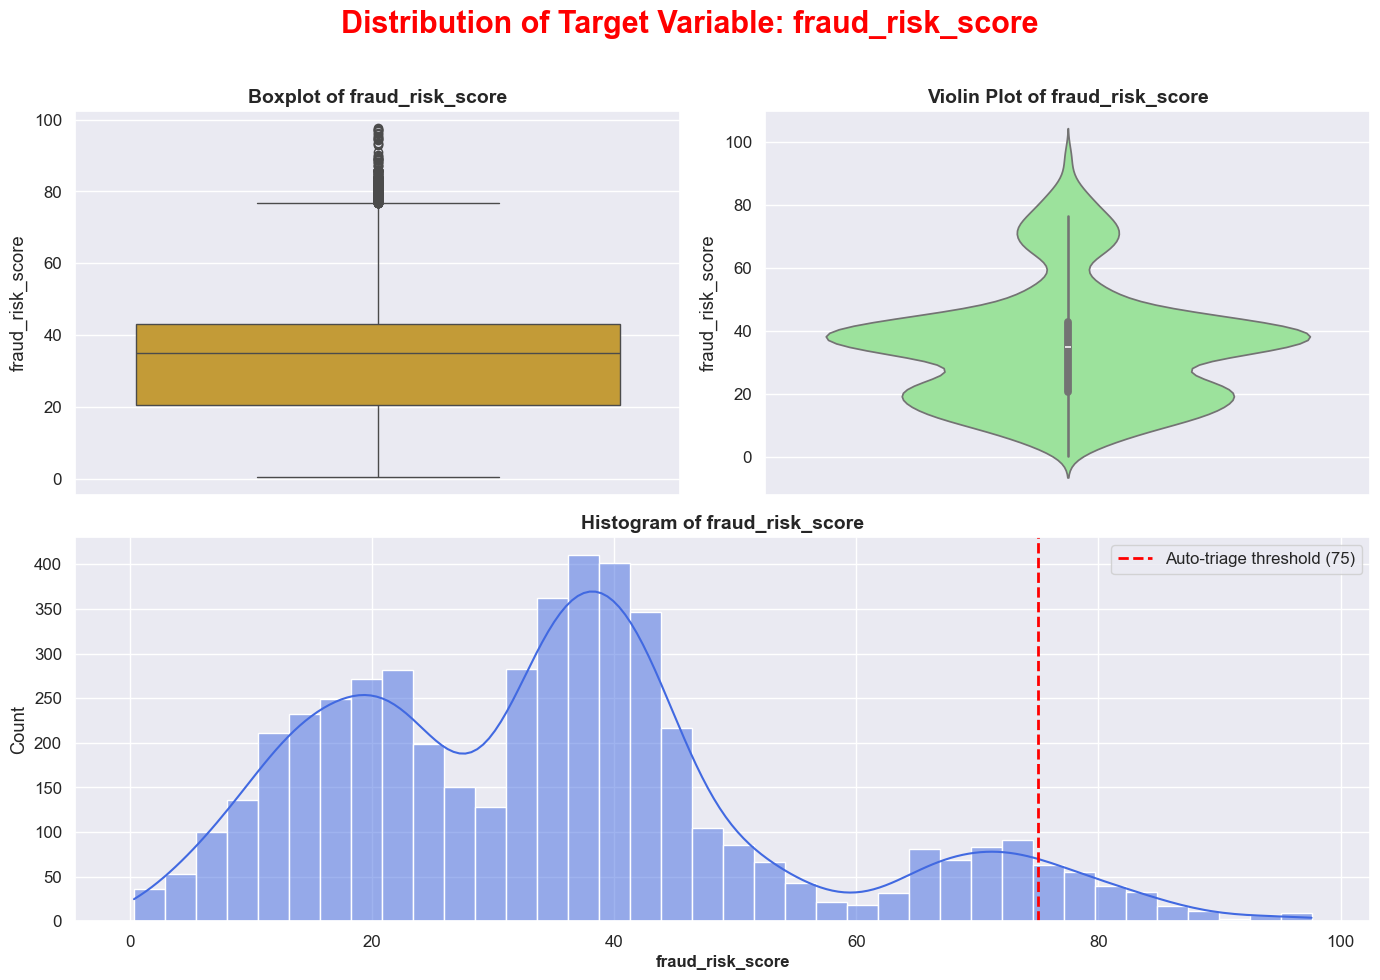

In [12]:
fig, axes = plt.subplot_mosaic([['A', 'B'], ['C', 'C']], figsize=(14, 10))
sns.boxplot(y=target, data=df, ax=axes['A'], color='goldenrod')
axes['A'].set_title(f"Boxplot of {target}", fontweight="bold", fontsize=14)

sns.violinplot(y=target, data=df, ax=axes['B'], color='lightgreen')
axes['B'].set_title(f"Violin Plot of {target}", fontweight="bold", fontsize=14)

sns.histplot(df[target], kde=True, ax=axes['C'], color='royalblue')
axes['C'].axvline(75, color='red', linestyle='--', linewidth=2, label='Auto-triage threshold (75)')
axes['C'].set_title(f"Histogram of {target}", fontweight="bold", fontsize=14)
axes['C'].set_xlabel(target, fontsize=12, fontweight="bold")
axes['C'].legend()

plt.suptitle(f"Distribution of Target Variable: {target}", fontsize=22, fontweight="bold", color='red')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## Risk Tier & Fraud Label Analysis

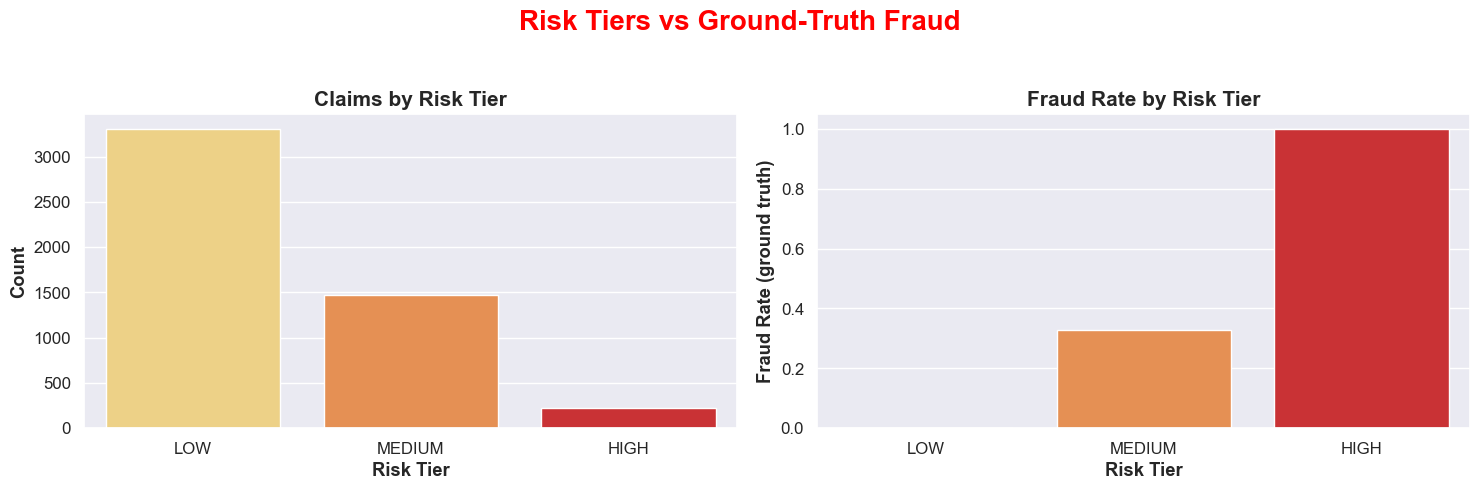

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

tier_order = ['LOW', 'MEDIUM', 'HIGH']
sns.countplot(x='risk_tier', data=df, order=tier_order, palette='YlOrRd', ax=axes[0])
axes[0].set_title("Claims by Risk Tier", fontsize=15, fontweight='bold')
axes[0].set_xlabel("Risk Tier", fontweight='bold'); axes[0].set_ylabel("Count", fontweight='bold')

sns.barplot(x='risk_tier', y=label, data=df, order=tier_order, palette='YlOrRd', errorbar=None, ax=axes[1])
axes[1].set_title("Fraud Rate by Risk Tier", fontsize=15, fontweight='bold')
axes[1].set_xlabel("Risk Tier", fontweight='bold'); axes[1].set_ylabel("Fraud Rate (ground truth)", fontweight='bold')

plt.suptitle("Risk Tiers vs Ground-Truth Fraud", fontsize=20, fontweight='bold', color='red')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Bivariate Analysis

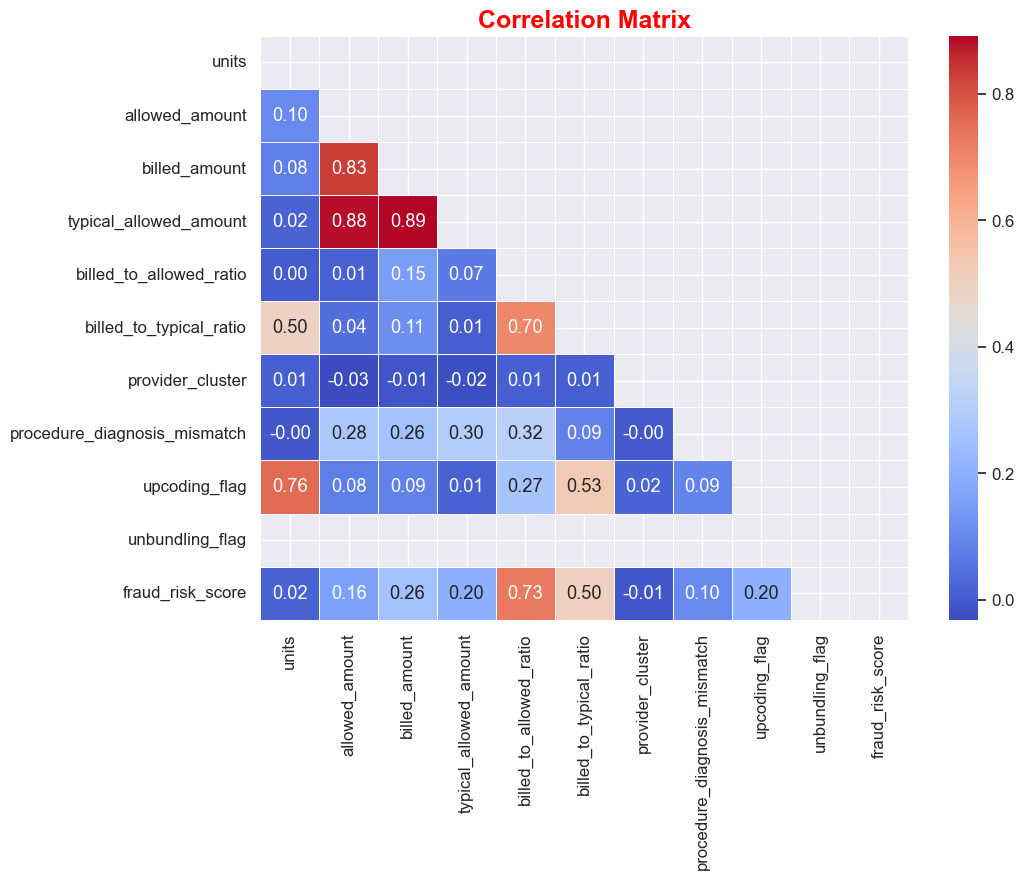

In [14]:
corr = df[numerical_features + [target]].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(11, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=18, fontweight="bold", color="red")
plt.tight_layout()
plt.show()

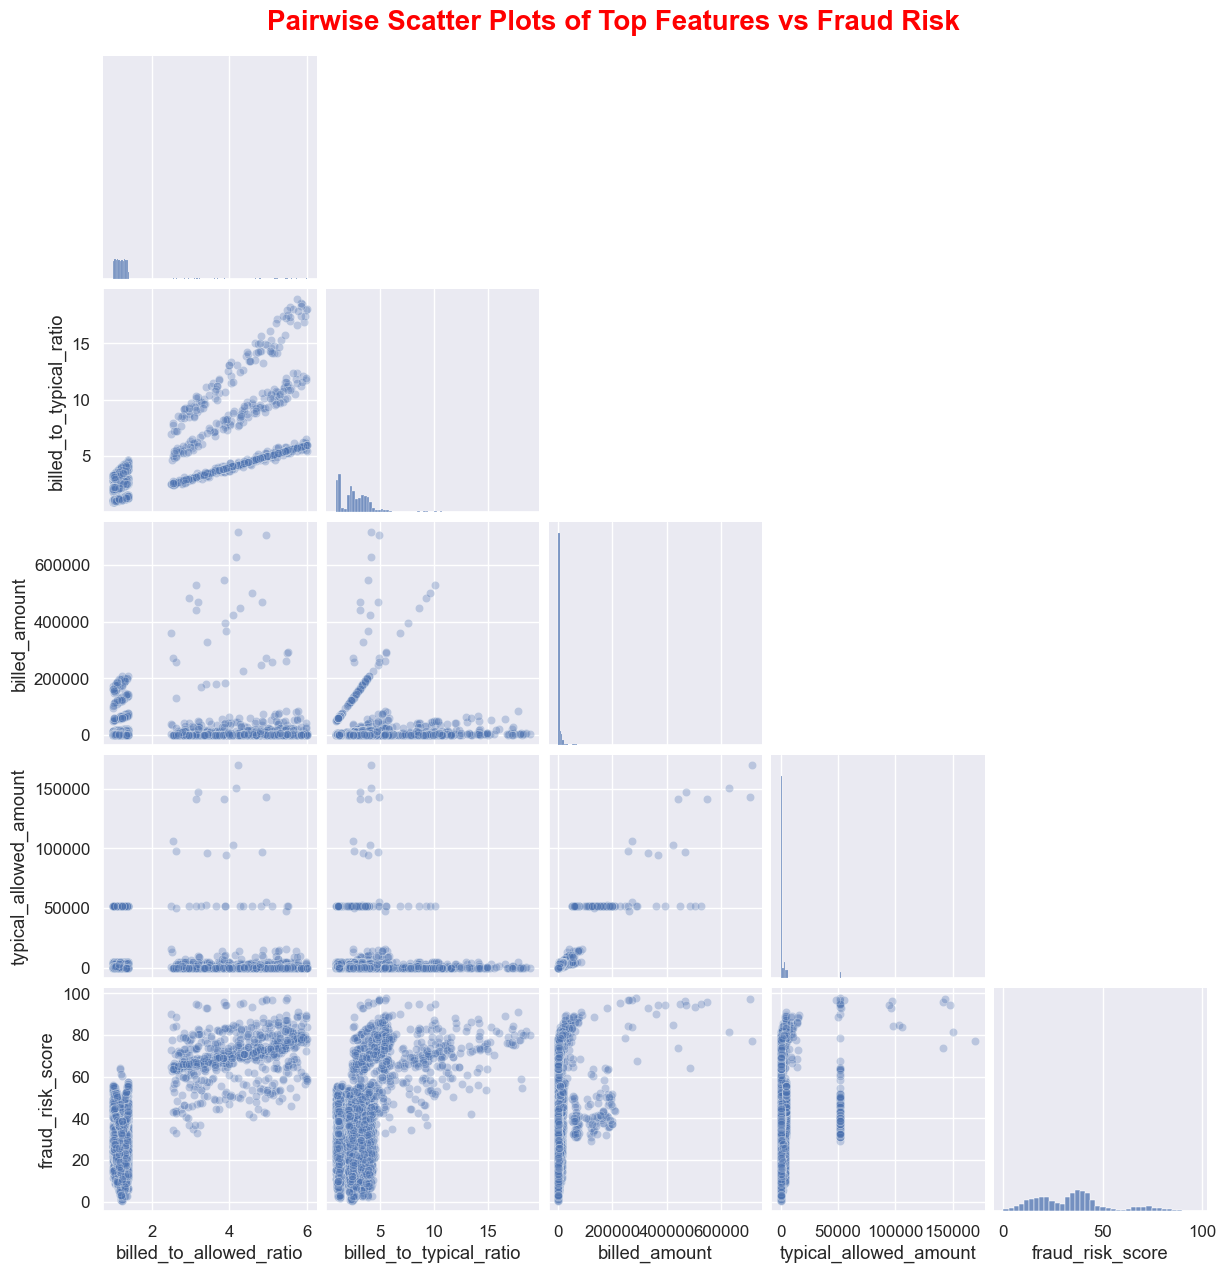

In [15]:
top_corr_features = corr[target].abs().sort_values(ascending=False)[1:5].index.tolist()

sns.pairplot(df, vars=top_corr_features + [target], kind='scatter', corner=True,
             plot_kws={'alpha': 0.3})
plt.suptitle("Pairwise Scatter Plots of Top Features vs Fraud Risk",
             fontsize=20, fontweight="bold", color="red", y=1.02)
plt.show()

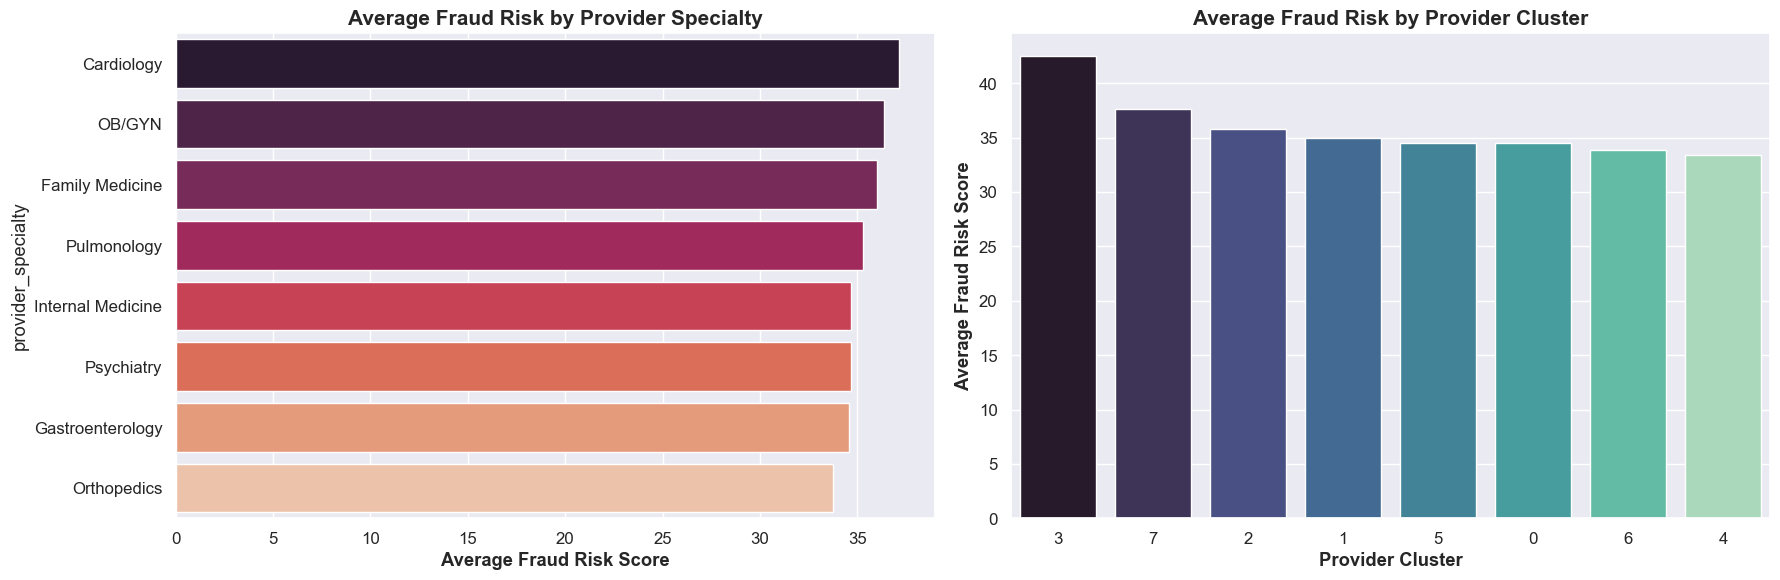

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

spec = df.groupby('provider_specialty')[target].mean().sort_values(ascending=False)
sns.barplot(x=spec.values, y=spec.index, palette='rocket', ax=axes[0])
axes[0].set_title("Average Fraud Risk by Provider Specialty", fontsize=15, fontweight='bold')
axes[0].set_xlabel("Average Fraud Risk Score", fontweight='bold')

clu = df.groupby('provider_cluster')[target].mean().sort_values(ascending=False)
sns.barplot(x=clu.index.astype(str), y=clu.values, palette='mako', order=clu.index.astype(str), ax=axes[1])
axes[1].set_title("Average Fraud Risk by Provider Cluster", fontsize=15, fontweight='bold')
axes[1].set_xlabel("Provider Cluster", fontweight='bold'); axes[1].set_ylabel("Average Fraud Risk Score", fontweight='bold')

plt.tight_layout()
plt.show()

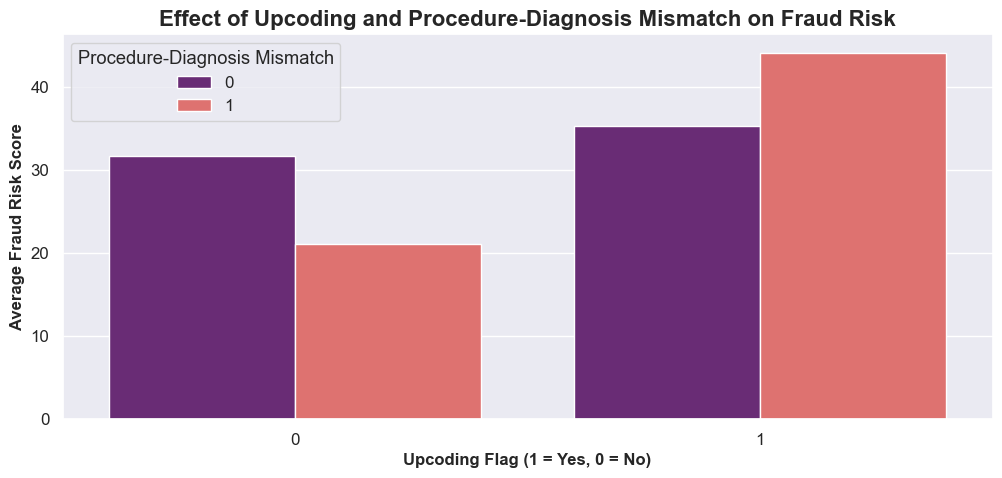

In [17]:
plt.figure(figsize=(12, 5))
sns.barplot(x='upcoding_flag', y=target, hue='procedure_diagnosis_mismatch', data=df, errorbar=None, palette='magma')
plt.title("Effect of Upcoding and Procedure-Diagnosis Mismatch on Fraud Risk", fontsize=16, fontweight='bold')
plt.xlabel("Upcoding Flag (1 = Yes, 0 = No)", fontsize=12, fontweight='bold')
plt.ylabel("Average Fraud Risk Score", fontsize=12, fontweight='bold')
plt.legend(title="Procedure-Diagnosis Mismatch")
plt.show()

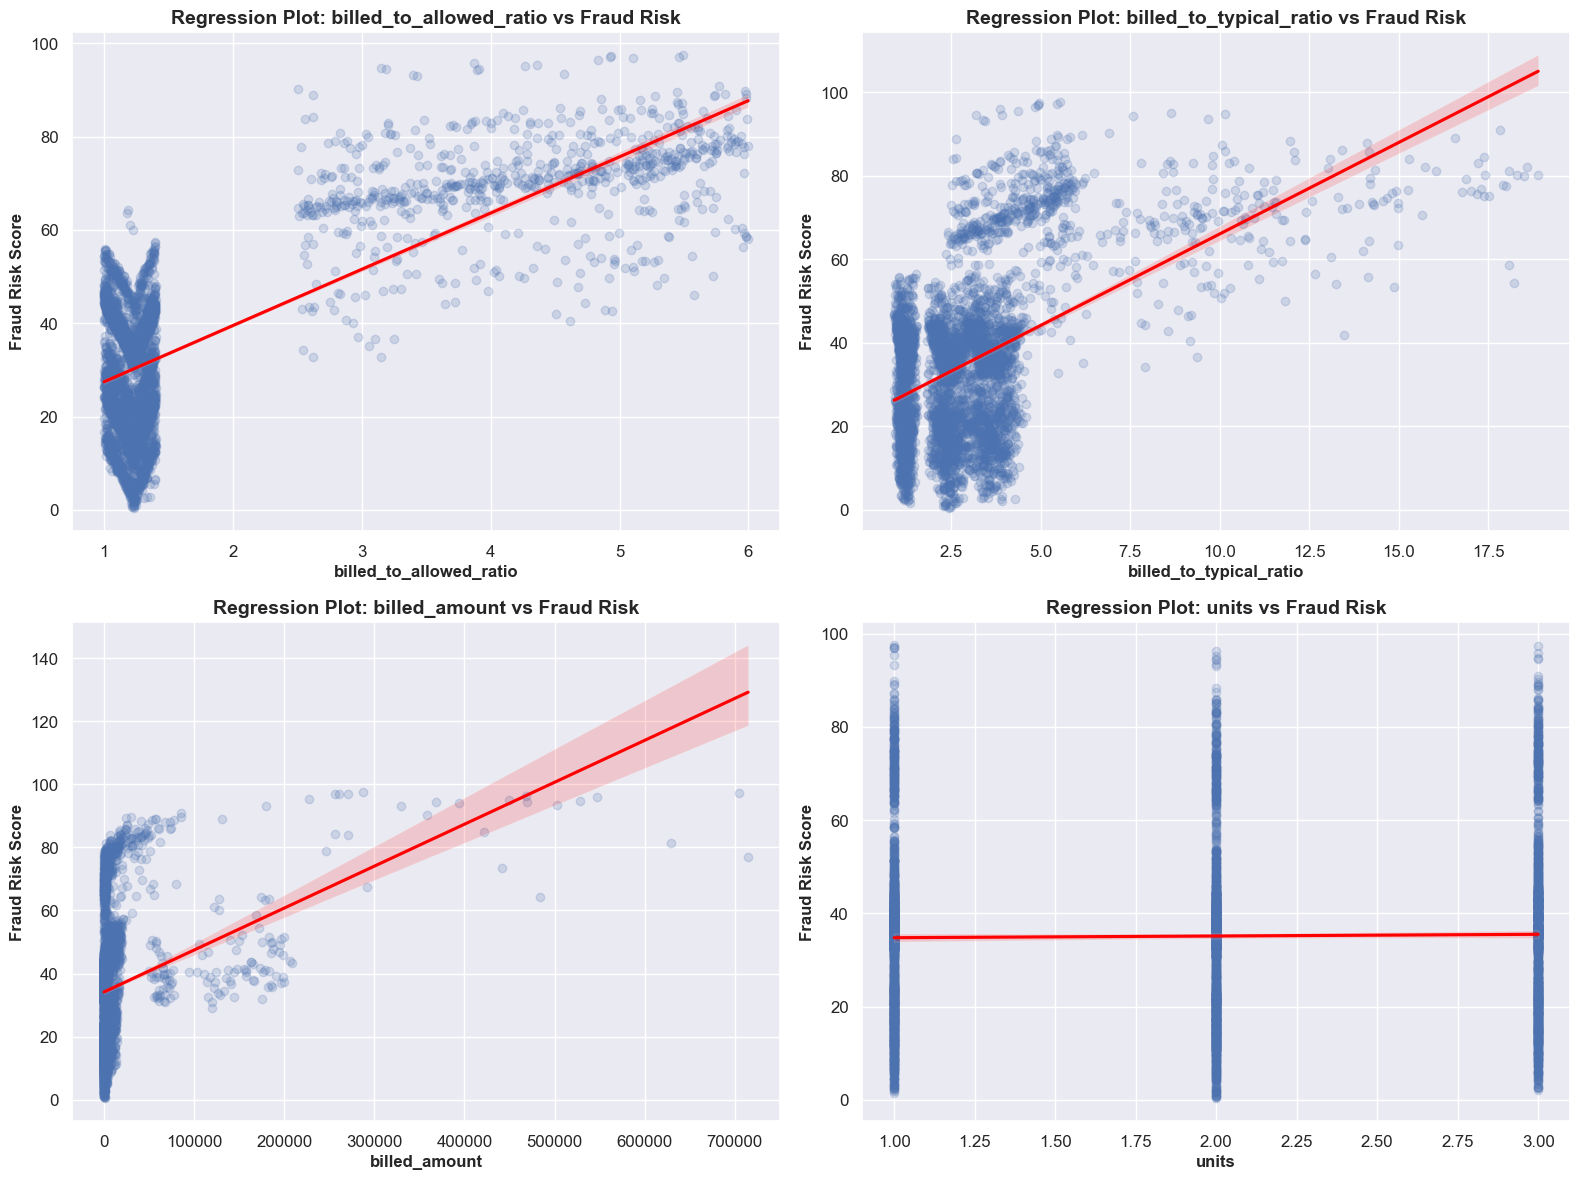

In [18]:
reg_feats = ['billed_to_allowed_ratio', 'billed_to_typical_ratio', 'billed_amount', 'units']
reg_feats = [f for f in reg_feats if f in df.columns]

plt.figure(figsize=(16, 12))
for i, feature in enumerate(reg_feats, 1):
    plt.subplot(2, 2, i)
    sns.regplot(x=feature, y=target, data=df, scatter_kws={'alpha': 0.2}, line_kws={'color': 'red'})
    plt.title(f"Regression Plot: {feature} vs Fraud Risk", fontsize=14, fontweight='bold')
    plt.xlabel(feature, fontsize=12, fontweight='bold')
    plt.ylabel("Fraud Risk Score", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# 🛠️ Feature Engineering & Preprocessing

<div class="alert alert-block alert-success" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    Before training models, we prepare the dataset. Feature engineering and preprocessing transform the raw claim fields into
    meaningful representations, encode categorical billing attributes, and scale numerical features so the models can learn
    clean separations between normal and fraudulent claims.
</div>

## 🔧 Key Preprocessing Steps

<div class="alert alert-block alert-info" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    <ul>
        <li><strong>Encoding Categorical Variables:</strong> Convert billing attributes into numerical form:
            <ul>
                <li><code>One-Hot Encoding</code> for nominal features such as <code>provider_specialty</code> and <code>provider_state</code>.</li>
            </ul>
        </li>
        <li><strong>Scaling Numerical Features:</strong> Normalize <code>billed_amount</code>, <code>units</code>, and the billing ratios so distance- and gradient-based models converge well.</li>
        <li><strong>Billing-Ratio Features:</strong> The <code>billed_to_allowed_ratio</code> and <code>billed_to_typical_ratio</code> are the strongest upcoding signals and are kept as core inputs.</li>
        <li><strong>Behavioural Cluster:</strong> The K-Means <code>provider_cluster</code> lets each claim be judged against its provider peer group instead of the whole population.</li>
        <li><strong>Leakage Control:</strong> Derived detection scores (anomaly score, clinical misalignment) and the ground-truth label are excluded from the supervised feature set to avoid target leakage.</li>
    </ul>
</div>

# 🏗️ Model Building

<div class="alert alert-block alert-success" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    In this section we train models to detect fraudulent claims. We first run an <strong>Isolation Forest</strong> for unsupervised
    anomaly detection, then train supervised classifiers to predict <strong>is_fraud_label</strong> from the engineered billing features,
    using stratified cross-validation. Our goal is high-precision detection so the compliance team reviews mostly real fraud.
</div>

## 🔭 Choice of Models

<div class="alert alert-block alert-info" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    Models suitable for this fraud-detection problem include:
    <ul>
        <li><strong>Isolation Forest:</strong> Unsupervised anomaly detector that isolates unusual billing patterns — no labels needed.</li>
        <li><strong>Random Forest Classifier:</strong> Handles nonlinear interactions, robust to outliers, gives feature importance.</li>
        <li><strong>Gradient Boosting (XGBoost / LightGBM / CatBoost):</strong> High performance on tabular claims data with complex interactions.</li>
        <li><strong>Logistic Regression:</strong> Interpretable baseline and meta-learner for stacking.</li>
    </ul>
    We start with an Isolation Forest, then build a stacked classifier ensemble.
</div>

In [19]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, classification_report
from sklearn.ensemble import RandomForestClassifier, IsolationForest

In [20]:
def model_trainer(model, X, y, test=None, nsplits=5, random_state=42, verbose=0, model_name=None):
    """Stratified K-Fold trainer that reports ROC-AUC / F1 and returns out-of-fold probabilities."""
    kfold = StratifiedKFold(n_splits=nsplits, shuffle=True, random_state=random_state)

    if isinstance(X, pd.DataFrame):
        X = X.to_numpy()
    y_array = y.to_numpy() if isinstance(y, pd.Series) else np.asarray(y)

    oof_train_preds = np.zeros(len(y_array))
    if test is not None:
        if isinstance(test, pd.DataFrame):
            test = test.to_numpy()
        oof_test_preds = np.zeros(len(test))

    oof_auc, oof_f1 = [], []

    for fold, (train_idx, val_idx) in enumerate(kfold.split(X, y_array), 1):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y_array[train_idx], y_array[val_idx]

        if model_name in ('xgb', 'cat'):
            model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=verbose)
        elif model_name == 'lgb':
            import lightgbm as lgb
            model.fit(X_train, y_train, eval_set=[(X_val, y_val)],
                      callbacks=[lgb.early_stopping(200, verbose=bool(verbose))])
        else:
            model.fit(X_train, y_train)

        y_prob = model.predict_proba(X_val)[:, 1]
        y_pred = (y_prob >= 0.5).astype(int)

        auc = roc_auc_score(y_val, y_prob)
        f1 = f1_score(y_val, y_pred, zero_division=0)
        oof_auc.append(auc); oof_f1.append(f1)
        oof_train_preds[val_idx] = y_prob

        if test is not None:
            oof_test_preds += model.predict_proba(test)[:, 1] / nsplits

        print(f"Fold {fold} -> ROC-AUC: {auc:.4f}, F1: {f1:.4f}")

    print(f"\nAverage Fold ROC-AUC: {np.mean(oof_auc):.4f} +/- {np.std(oof_auc):.4f}")
    print(f"Average Fold F1 Score: {np.mean(oof_f1):.4f} +/- {np.std(oof_f1):.4f}")

    if test is not None:
        return oof_train_preds, oof_test_preds
    return oof_train_preds

In [21]:
numeric_transformer = MinMaxScaler()
categorical_transformer = OneHotEncoder(drop='first', handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features),
    ]
)

In [22]:
X = df[features].copy()
y = df[label].astype(int)

X_processed = preprocessor.fit_transform(X)
try:
    X_processed = X_processed.toarray()
except AttributeError:
    pass

print("Processed feature matrix:", X_processed.shape)
print("Fraud prevalence:", round(y.mean() * 100, 2), "%")

Processed feature matrix: (5000, 22)
Fraud prevalence: 14.26 %


## Unsupervised: Isolation Forest

In [23]:
iso = IsolationForest(n_estimators=300, contamination=float(y.mean()), random_state=42)
iso.fit(X_processed)

# Higher score = more anomalous
iso_anomaly = -iso.score_samples(X_processed)
iso_pred = (iso.predict(X_processed) == -1).astype(int)

print("Isolation Forest detection vs ground truth:")
print(f"  Precision: {precision_score(y, iso_pred, zero_division=0):.4f}")
print(f"  Recall   : {recall_score(y, iso_pred, zero_division=0):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y, iso_anomaly):.4f}")

Isolation Forest detection vs ground truth:
  Precision: 0.5498
  Recall   : 0.5498
  ROC-AUC  : 0.8541


## Supervised Classifiers (Stratified CV)

In [24]:
oof_train_preds = pd.DataFrame()
oof_test_preds = pd.DataFrame()   # placeholder for a real hold-out / test split

In [25]:
rf = RandomForestClassifier(n_estimators=400, max_depth=None, class_weight='balanced',
                            n_jobs=-1, random_state=42)
oof_train_preds['rf'] = model_trainer(rf, X_processed, y, nsplits=5)

Fold 1 -> ROC-AUC: 1.0000, F1: 1.0000


Fold 2 -> ROC-AUC: 1.0000, F1: 1.0000


Fold 3 -> ROC-AUC: 1.0000, F1: 1.0000


Fold 4 -> ROC-AUC: 1.0000, F1: 1.0000


Fold 5 -> ROC-AUC: 1.0000, F1: 1.0000

Average Fold ROC-AUC: 1.0000 +/- 0.0000
Average Fold F1 Score: 1.0000 +/- 0.0000


In [26]:
from xgboost import XGBClassifier

xgb_clf = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    n_estimators=2000,
    learning_rate=0.02,
    max_depth=5,
    colsample_bytree=0.7,
    subsample=0.9,
    early_stopping_rounds=200,
    scale_pos_weight=float((y == 0).sum() / max((y == 1).sum(), 1)),
    random_state=42,
)
oof_train_preds['xgb'] = model_trainer(xgb_clf, X_processed, y, nsplits=5, model_name='xgb', verbose=0)

Fold 1 -> ROC-AUC: 1.0000, F1: 0.9930


Fold 2 -> ROC-AUC: 1.0000, F1: 1.0000


Fold 3 -> ROC-AUC: 1.0000, F1: 0.9965


Fold 4 -> ROC-AUC: 1.0000, F1: 0.9965


Fold 5 -> ROC-AUC: 1.0000, F1: 0.9965

Average Fold ROC-AUC: 1.0000 +/- 0.0000
Average Fold F1 Score: 0.9965 +/- 0.0022


In [27]:
from lightgbm import LGBMClassifier

lgb_clf = LGBMClassifier(
    objective="binary",
    metric="auc",
    n_estimators=3000,
    learning_rate=0.02,
    max_depth=6,
    class_weight='balanced',
    random_state=42,
    verbosity=-1,
)
oof_train_preds['lgb'] = model_trainer(lgb_clf, X_processed, y, nsplits=5, model_name='lgb', verbose=False)

Fold 1 -> ROC-AUC: 1.0000, F1: 1.0000
Fold 2 -> ROC-AUC: 1.0000, F1: 1.0000


Fold 3 -> ROC-AUC: 1.0000, F1: 0.9965
Fold 4 -> ROC-AUC: 1.0000, F1: 1.0000
Fold 5 -> ROC-AUC: 1.0000, F1: 1.0000

Average Fold ROC-AUC: 1.0000 +/- 0.0000
Average Fold F1 Score: 0.9993 +/- 0.0014


In [28]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb = HistGradientBoostingClassifier(max_iter=1500, learning_rate=0.02,
                                     early_stopping=True, n_iter_no_change=200, random_state=42)
oof_train_preds['hgb'] = model_trainer(hgb, X_processed, y, nsplits=5)

Fold 1 -> ROC-AUC: 1.0000, F1: 0.9965


Fold 2 -> ROC-AUC: 1.0000, F1: 0.9858


Fold 3 -> ROC-AUC: 1.0000, F1: 0.9965


Fold 4 -> ROC-AUC: 1.0000, F1: 1.0000


Fold 5 -> ROC-AUC: 1.0000, F1: 1.0000

Average Fold ROC-AUC: 1.0000 +/- 0.0000
Average Fold F1 Score: 0.9958 +/- 0.0052


## Meta Learner

In [29]:
from sklearn.linear_model import LogisticRegression

meta = LogisticRegression(max_iter=2000, class_weight='balanced')
meta_oof = model_trainer(meta, oof_train_preds.values, y, nsplits=5, random_state=101)

df['model_fraud_prob'] = meta_oof

Fold 1 -> ROC-AUC: 1.0000, F1: 1.0000
Fold 2 -> ROC-AUC: 1.0000, F1: 1.0000
Fold 3 -> ROC-AUC: 1.0000, F1: 1.0000
Fold 4 -> ROC-AUC: 1.0000, F1: 1.0000
Fold 5 -> ROC-AUC: 1.0000, F1: 1.0000

Average Fold ROC-AUC: 1.0000 +/- 0.0000
Average Fold F1 Score: 1.0000 +/- 0.0000


## Feature Importance

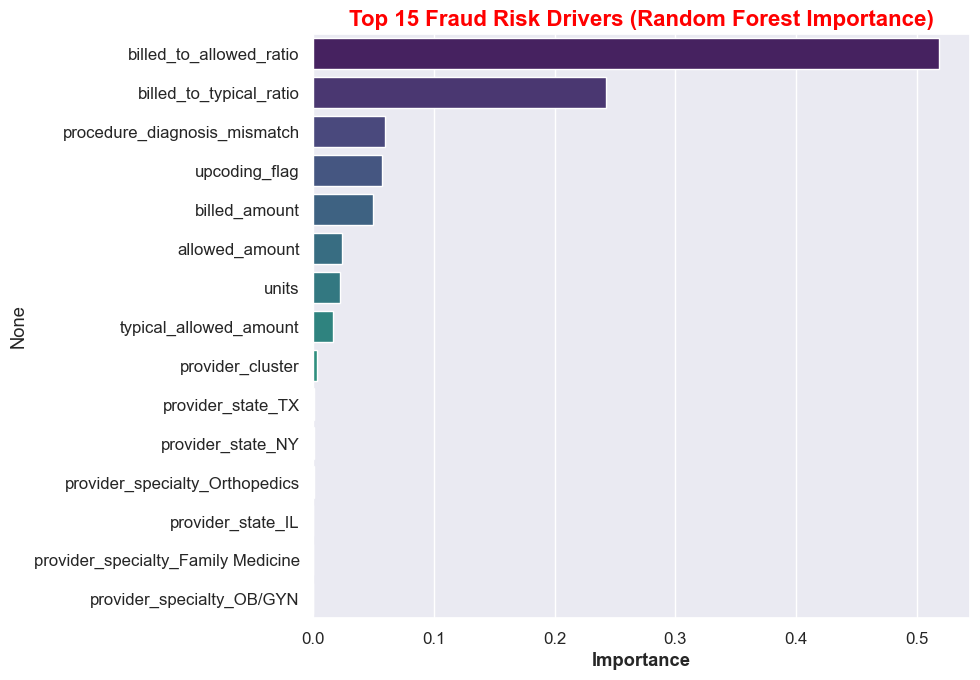

In [30]:
# Refit a Random Forest on the full data for global feature importance
rf_full = RandomForestClassifier(n_estimators=400, class_weight='balanced', n_jobs=-1, random_state=42)
rf_full.fit(X_processed, y)

feat_names = (numerical_features +
              list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)))
importances = pd.Series(rf_full.feature_importances_, index=feat_names).sort_values(ascending=False)[:15]

plt.figure(figsize=(10, 7))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title("Top 15 Fraud Risk Drivers (Random Forest Importance)", fontsize=16, fontweight='bold', color='red')
plt.xlabel("Importance", fontweight='bold')
plt.tight_layout()
plt.show()

# High-Risk Claim Queue

<div class="alert alert-block alert-warning" style="font-family: verdana; font-size: 18px; line-height: 1.6em; border-radius: 1.3em;">
    The compliance team only reviews the highest-risk claims. Below we rank claims by the model's fraud probability,
    export the auto-triage queue to <code>high_risk_claims.csv</code>, and report the precision of the triage decision
    against the ground-truth label.
</div>

In [31]:
queue = (df.sort_values('model_fraud_prob', ascending=False)
           [['claim_id', 'provider_id', 'provider_specialty', 'provider_state',
             'billed_amount', 'billed_to_allowed_ratio', 'upcoding_flag',
             'procedure_diagnosis_mismatch', 'fraud_risk_score', 'risk_tier',
             'model_fraud_prob', 'is_fraud_label']])

high_risk = queue[queue['fraud_risk_score'] > 75]
high_risk.to_csv("high_risk_claims.csv", index=False)

print(f"High-risk claims (score > 75): {len(high_risk):,}")
if len(high_risk):
    print(f"Auto-triage precision        : {high_risk['is_fraud_label'].mean():.3f}")
high_risk.head(10)

High-risk claims (score > 75): 223
Auto-triage precision        : 1.000


,claim_id,provider_id,provider_specialty,provider_state,billed_amount,billed_to_allowed_ratio,upcoding_flag,procedure_diagnosis_mismatch,fraud_risk_score,risk_tier,model_fraud_prob,is_fraud_label
3531,CLM00003531,PRV00057,Internal Medicine,TX,2142.08,5.637943,1,1,77.36,HIGH,0.998752,1
1469,CLM00001469,PRV00093,Cardiology,IL,29572.66,5.971633,1,0,89.73,HIGH,0.998743,1
4889,CLM00004889,PRV00098,Orthopedics,TX,1888.09,5.490549,1,1,76.81,HIGH,0.998726,1
1787,CLM00001787,PRV00009,Gastroenterology,NY,246910.32,4.803113,1,1,78.76,HIGH,0.998723,1
1940,CLM00001940,PRV00041,Internal Medicine,IL,48243.65,5.442724,1,0,87.43,HIGH,0.998723,1
3549,CLM00003549,PRV00030,Psychiatry,IL,1359.44,5.962718,1,1,76.23,HIGH,0.998702,1
2316,CLM00002316,PRV00081,Psychiatry,IL,7046.36,5.604581,1,1,82.19,HIGH,0.998702,1
4481,CLM00004481,PRV00040,Internal Medicine,CA,1297.63,5.549934,1,1,76.82,HIGH,0.998700,1
3996,CLM00003996,PRV00109,Cardiology,IL,31178.93,3.031162,1,0,80.60,HIGH,0.998700,1
4198,CLM00004198,PRV00061,Family Medicine,CA,16183.79,4.475866,1,1,80.28,HIGH,0.998698,1


# 🏁 Conclusion

<div class="alert alert-block alert-success" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    In this notebook we built an explainable healthcare claims fraud-detection workflow:
    <ul>
        <li><strong>Explored</strong> the billing behaviour of providers and the distribution of the composite fraud risk score.</li>
        <li><strong>Engineered & preprocessed</strong> billing-ratio and behavioural-cluster features while controlling for target leakage.</li>
        <li><strong>Detected anomalies</strong> with an Isolation Forest and <strong>classified fraud</strong> with a stacked Random Forest / XGBoost / LightGBM / HistGradientBoosting ensemble.</li>
        <li><strong>Explained</strong> the model with feature importance and produced an auditable high-risk claim queue for human review.</li>
    </ul>
    The result is a high-precision, explainable triage system that focuses scarce compliance resources on the claims most
    likely to be fraudulent.
    <br><br>
    <i><b>Thank you for reading, happy building!</b></i>
</div>

<center>
    <img src="https://upload.wikimedia.org/wikipedia/commons/f/f1/Animated-thank-you-image-0078.gif" alt="thank you" height="220" width="400">
</center>

<h2 style="color: red; text-align: center;">🙏 Thank You!</h2>